In [1]:
import json
from pathlib import Path
from typing import Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)

In [2]:
BASE_DIR = Path("../assets/experiments/2026-03-12_17-29-25")
# BASE_DIR = Path("../assets/experiments/2026-03-11_15-09-57")
# BASE_DIR = Path("../assets/experiments/2026-03-11_10-48-53__5-15_secs")

BALANCER_DIR = BASE_DIR / "baseline"
REPL_NO_ADAPT_DIR = BASE_DIR / "non_adaptive"
REPL_ADAPT_DIR = BASE_DIR / "adaptive"

print(BASE_DIR)

..\assets\experiments\2026-03-12_17-29-25


In [3]:
def load_experiment(path: Path) -> Dict[str, Any]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [4]:
def extract_method(data):
    factors = data["factors"]

    balancer = factors.get("balancer")
    replication = factors.get("replication")
    adaptive = factors.get("adaptive")

    if replication:
        return f"{balancer} | {replication} | {'adaptive' if adaptive else 'no_adaptive'}"

    return f"{balancer} | no_replication"

In [5]:
def flatten_requests(data, method, group):
    rows = []

    for req in data["requests"]:

        upstream = req.get("upstream", {})
        signals = req.get("signals", {})

        sockets = upstream.get("sockets", [])
        winner = upstream.get("winner_socket")

        if sockets:
            replicas = len(sockets)
        else:
            replicas = 1

        rows.append({
            "method": method,
            "group": group,

            "req_id": req["req_id"],
            "endpoint": req["endpoint"],

            "latency_ms": req["latency_ms"],
            "status": req["status"],
            "ok": req["ok"],

            "error_kind": req.get("error_kind"),
            "error": req.get("error"),

            "winner_socket": winner,
            "backend_port": signals.get("port"),

            "replicas": replicas,

            "cpu_util": signals.get("cpu_util"),
            "mem_util": signals.get("mem_util"),
            "cpu_burn": signals.get("cpu_burn"),
            "mem_burn": signals.get("mem_burn"),
        })

    return pd.DataFrame(rows)

In [6]:
def load_folder(folder, group):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        method = extract_method(data)

        df = flatten_requests(data, method, group)

        dfs.append(df)

    return dfs


dfs = []

dfs += load_folder(BALANCER_DIR, "balancer_only")
dfs += load_folder(REPL_NO_ADAPT_DIR, "replication_no_adaptive")
dfs += load_folder(REPL_ADAPT_DIR, "replication_adaptive")

df = pd.concat(dfs, ignore_index=True)

df.head()

,method,group,req_id,endpoint,latency_ms,status,ok,error_kind,error,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,airm | no_replication,balancer_only,req-0,mem?seconds=15&mb=75,20399.3242,200,True,None,None,GQW1_50051,8004.0,1,39.4,19.7,None,True
1,airm | no_replication,balancer_only,req-1,mem?seconds=14&mb=75,14201.1436,200,True,None,None,GQW2_50051,8001.0,1,36.9,19.7,None,True
2,airm | no_replication,balancer_only,req-2,cpu?seconds=11,11039.0685,200,True,None,None,GQW2_50051,8001.0,1,43.7,18.8,True,None
3,airm | no_replication,balancer_only,req-3,cpu?seconds=15,15037.3797,200,True,None,None,GQW6_50051,8001.0,1,41.9,19.7,True,None
4,airm | no_replication,balancer_only,req-4,mem?seconds=11&mb=75,11134.7649,200,True,None,None,GQW6_50051,8001.0,1,43.5,18.7,None,True


In [7]:
def p50(x):
    return np.percentile(x, 50)


def p95(x):
    return np.percentile(x, 95)


def p99(x):
    return np.percentile(x, 99)

# Latency

In [8]:
latency_stats = (
    df
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

latency_stats

,mean,p50,p95,p99
method,,,,
electre | no_replication,14357.129986,13178.84220,23068.532915,33577.373395
airm | no_replication,14414.669479,13271.63450,23863.939220,36492.537825
airm | hedged | no_adaptive,14609.620943,14039.19465,22102.242630,26987.915575
topsis | no_replication,14712.644014,13770.76435,24654.237880,33949.617646
electre | hedged | adaptive,14744.664716,14042.79490,24000.735310,30586.832080
topsis | hedged | adaptive,14759.851211,13620.61365,24196.879710,36031.783660
topsis | hedged | no_adaptive,14811.459721,14050.65710,23420.169650,25587.389401
airm | hedged | adaptive,14897.181459,13996.28005,24793.572075,36073.006065
electre | hedged | no_adaptive,14968.042264,14167.01885,23459.654615,28106.431707


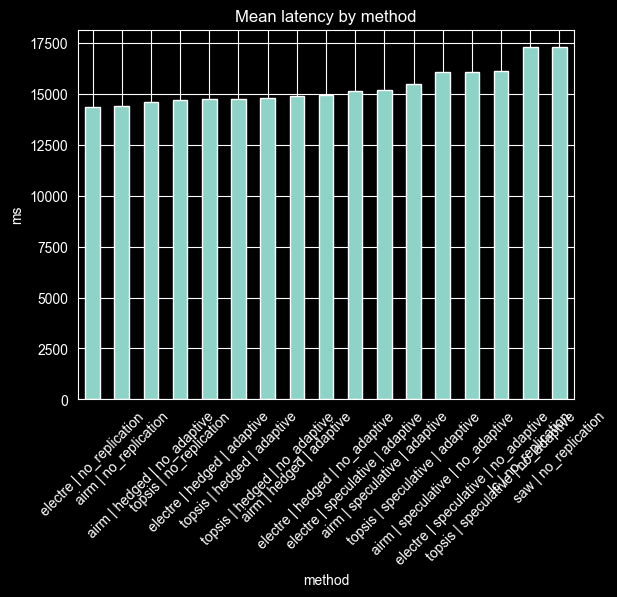

In [9]:
latency_stats["mean"].plot(kind="bar")

plt.title("Mean latency by method")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

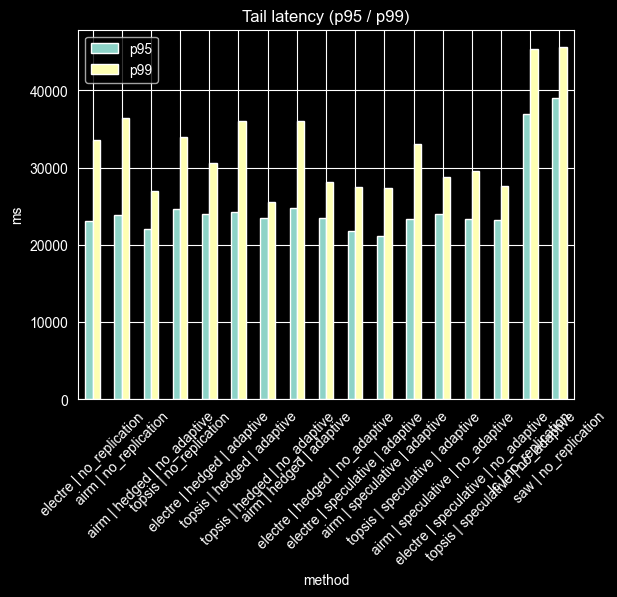

In [10]:
latency_stats[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency (p95 / p99)")
plt.ylabel("ms")
plt.xticks(rotation=45)

plt.show()

# WA

In [11]:
wa_stats = (
    df
    .groupby("method")["replicas"]
    .agg(
        mean="mean",
        p95=p95,
        max="max"
    )
    .sort_values("mean")
)

wa_stats

,mean,p95,max
method,,,
airm | no_replication,1.000,1.0,1
electre | no_replication,1.000,1.0,1
lc | no_replication,1.000,1.0,1
saw | no_replication,1.000,1.0,1
topsis | no_replication,1.000,1.0,1
airm | hedged | adaptive,1.510,2.0,3
topsis | hedged | adaptive,1.523,2.0,3
electre | hedged | adaptive,1.524,2.0,3
topsis | speculative | adaptive,2.444,3.0,3


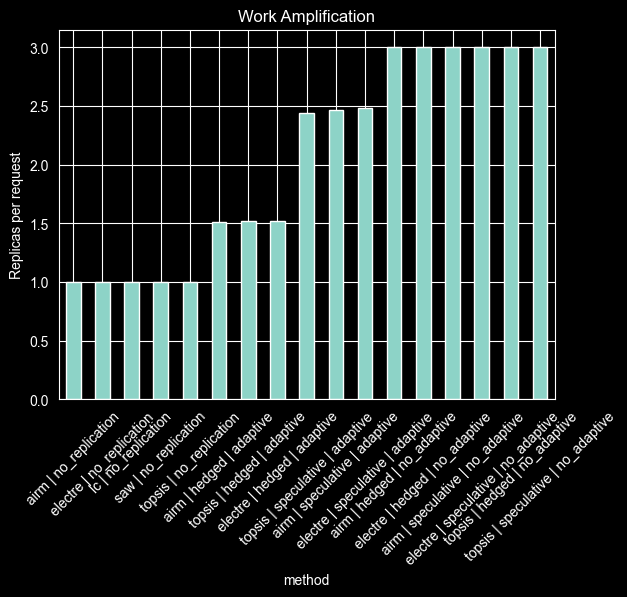

In [12]:
wa_stats["mean"].plot(kind="bar")

plt.title("Work Amplification")
plt.ylabel("Replicas per request")

plt.xticks(rotation=45)

plt.show()

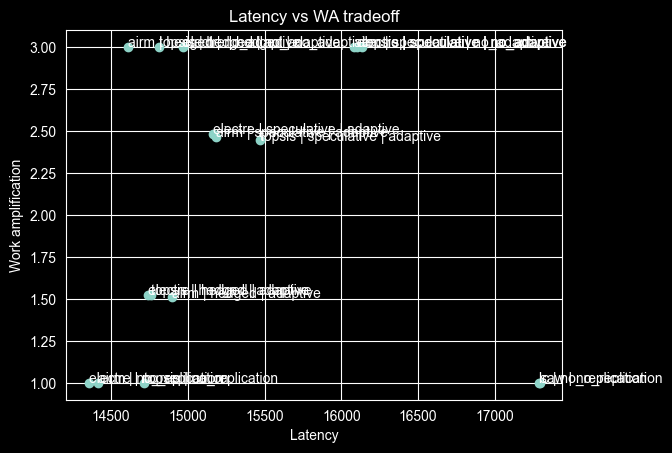

In [13]:
tradeoff = latency_stats.merge(
    wa_stats,
    left_index=True,
    right_index=True
)

plt.scatter(tradeoff["mean_x"], tradeoff["mean_y"])

for name, row in tradeoff.iterrows():
    plt.text(row["mean_x"], row["mean_y"], name)

plt.xlabel("Latency")
plt.ylabel("Work amplification")

plt.title("Latency vs WA tradeoff")

plt.show()

# CPU / MEM

In [14]:
socket_dist = (
    df
    .groupby(["method", "winner_socket"])
    .size()
    .reset_index(name="count")
)

socket_dist.head()

,method,winner_socket,count
0,airm | hedged | adaptive,,14
1,airm | hedged | adaptive,192.168.68.50_GQW_50051,210
2,airm | hedged | adaptive,192.168.68.55_GQW1_50051,95
3,airm | hedged | adaptive,192.168.68.58_GQW2_50051,189
4,airm | hedged | adaptive,192.168.68.60_GQW3_50051,50


In [15]:
balance = (
    socket_dist
    .groupby("method")["count"]
    .agg(
        mean="mean",
        std="std"
    )
)

balance["cv"] = balance["std"] / balance["mean"]

balance.sort_values("cv")

,mean,std,cv
method,,,
airm | speculative | adaptive,142.857143,21.843600,0.152905
topsis | speculative | no_adaptive,142.857143,42.799644,0.299598
topsis | no_replication,141.571429,47.535450,0.335770
airm | hedged | no_adaptive,142.857143,56.363193,0.394542
airm | speculative | no_adaptive,125.000000,50.990195,0.407922
electre | hedged | adaptive,142.857143,66.038950,0.462273
electre | speculative | adaptive,142.857143,67.199773,0.470398
electre | speculative | no_adaptive,125.000000,64.659548,0.517276
electre | hedged | no_adaptive,142.857143,74.241562,0.519691


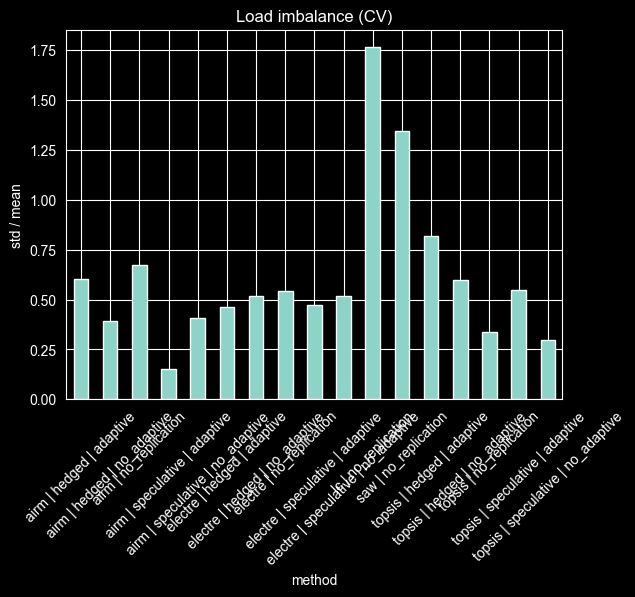

In [16]:
balance["cv"].plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

In [17]:
df["algorithm"] = df["method"].str.split(" | ").str[0]

compare = (
    df.groupby(["algorithm", "group"])["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
    .unstack("group")
)

compare

mean                                               \
group     balancer_only replication_adaptive replication_no_adaptive   
algorithm                                                              
airm       14414.669479         15039.218530            15345.092957   
electre    14357.129986         14956.102702            15533.593468   
lc         17289.543829                  NaN                     NaN   
saw        17291.975337                  NaN                     NaN   
topsis     14712.644014         15116.249205            15471.471761   

                    p95                                               \
group     balancer_only replication_adaptive replication_no_adaptive   
algorithm                                                              
airm       23863.939220          22671.00286            23167.309105   
electre    23068.532915          22615.98242            23408.193985   
lc         36952.810005                  NaN                     NaN   
saw        39008.382060                  NaN                     NaN   
topsis     24654.237880          23829.94034            23389.680485   

                    p99                                               
group     balancer_only replication_adaptive replication_no_adaptive  
algorithm                                                             
airm       36492.537825         30814.103873            28584.051124  
electre    33577.373395         29544.905537            29270.161324  
lc         45306.836352                  NaN                     NaN  
saw        45583.276771                  NaN                     NaN  
topsis     33949.617646         34094.085432            26855.574799

In [18]:
improvement = pd.DataFrame({
    "mean_improvement_%": (
            (compare["mean"]["balancer_only"] - compare["mean"]["replication_no_adaptive"])
            / compare["mean"]["balancer_only"] * 100
    ),
    "p95_improvement_%": (
            (compare["p95"]["balancer_only"] - compare["p95"]["replication_no_adaptive"])
            / compare["p95"]["balancer_only"] * 100
    ),
    "p99_improvement_%": (
            (compare["p99"]["balancer_only"] - compare["p99"]["replication_no_adaptive"])
            / compare["p99"]["balancer_only"] * 100
    ),
})

print("Replication improvement per algorithm (%):")
improvement.sort_values("p99_improvement_%", ascending=False)

Replication improvement per algorithm (%):


,mean_improvement_%,p95_improvement_%,p99_improvement_%
algorithm,,,
airm,-6.454699,2.919175,21.671517
topsis,-5.157657,5.129168,20.895796
electre,-8.194280,-1.472400,12.827722
lc,NaN,NaN,NaN
saw,NaN,NaN,NaN


In [19]:
adaptive_gain = pd.DataFrame({

    # replication vs baseline
    "replication_vs_baseline_mean_%": (
            (compare["mean"]["balancer_only"] - compare["mean"]["replication_no_adaptive"])
            / compare["mean"]["balancer_only"] * 100
    ),
    "replication_vs_baseline_p95_%": (
            (compare["p95"]["balancer_only"] - compare["p95"]["replication_no_adaptive"])
            / compare["p95"]["balancer_only"] * 100
    ),
    "replication_vs_baseline_p99_%": (
            (compare["p99"]["balancer_only"] - compare["p99"]["replication_no_adaptive"])
            / compare["p99"]["balancer_only"] * 100
    ),

    # adaptive vs non-adaptive replication
    "adaptive_vs_nonadaptive_mean_%": (
            (compare["mean"]["replication_no_adaptive"] - compare["mean"]["replication_adaptive"])
            / compare["mean"]["replication_no_adaptive"] * 100
    ),
    "adaptive_vs_nonadaptive_p95_%": (
            (compare["p95"]["replication_no_adaptive"] - compare["p95"]["replication_adaptive"])
            / compare["p95"]["replication_no_adaptive"] * 100
    ),
    "adaptive_vs_nonadaptive_p99_%": (
            (compare["p99"]["replication_no_adaptive"] - compare["p99"]["replication_adaptive"])
            / compare["p99"]["replication_no_adaptive"] * 100
    ),

    # adaptive vs baseline (итоговый эффект)
    "adaptive_vs_baseline_mean_%": (
            (compare["mean"]["balancer_only"] - compare["mean"]["replication_adaptive"])
            / compare["mean"]["balancer_only"] * 100
    ),
    "adaptive_vs_baseline_p95_%": (
            (compare["p95"]["balancer_only"] - compare["p95"]["replication_adaptive"])
            / compare["p95"]["balancer_only"] * 100
    ),
    "adaptive_vs_baseline_p99_%": (
            (compare["p99"]["balancer_only"] - compare["p99"]["replication_adaptive"])
            / compare["p99"]["balancer_only"] * 100
    ),
})

adaptive_gain = adaptive_gain.round(2)

print("Replication and adaptive improvements (%):")
adaptive_gain.sort_values("adaptive_vs_baseline_p99_%", ascending=False)

Replication and adaptive improvements (%):


,replication_vs_baseline_mean_%,replication_vs_baseline_p95_%,replication_vs_baseline_p99_%,adaptive_vs_nonadaptive_mean_%,adaptive_vs_nonadaptive_p95_%,adaptive_vs_nonadaptive_p99_%,adaptive_vs_baseline_mean_%,adaptive_vs_baseline_p95_%,adaptive_vs_baseline_p99_%
algorithm,,,,,,,,,
airm,-6.45,2.92,21.67,1.99,2.14,-7.80,-4.33,5.00,15.56
electre,-8.19,-1.47,12.83,3.72,3.38,-0.94,-4.17,1.96,12.01
topsis,-5.16,5.13,20.90,2.30,-1.88,-26.95,-2.74,3.34,-0.43
lc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
saw,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


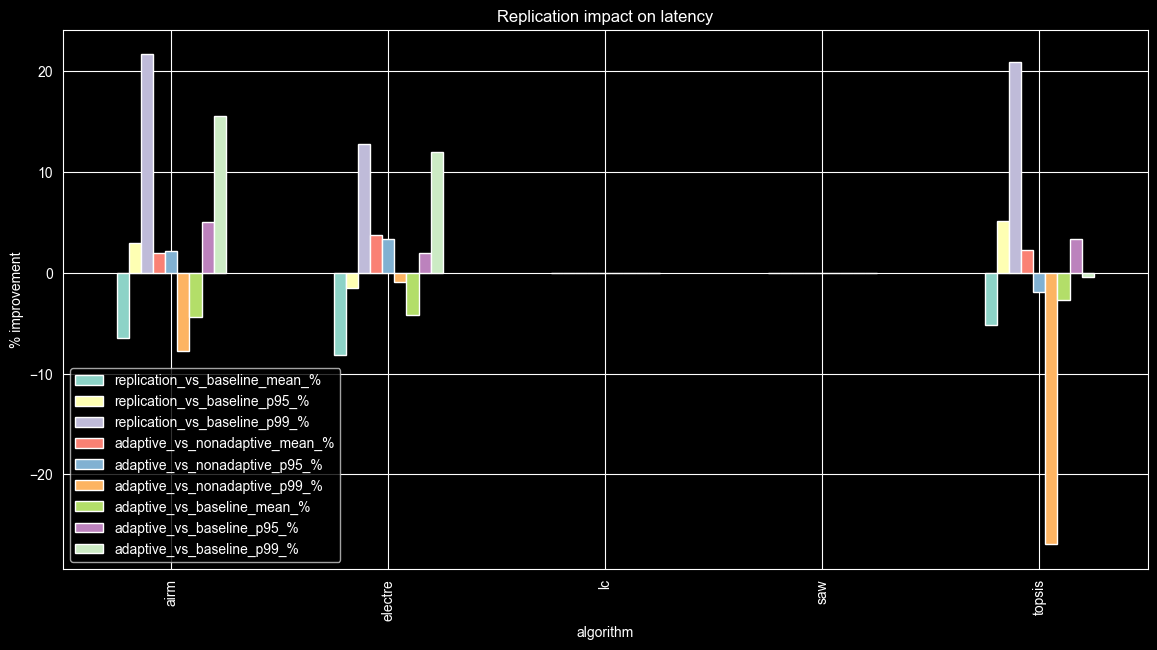

In [20]:
fig, ax = plt.subplots(figsize=(14,7))

adaptive_gain.plot(kind="bar", ax=ax)

ax.set_title("Replication impact on latency")
ax.set_ylabel("% improvement")

plt.show()

# Выгода адаптивности

In [21]:
wa_group = (
    df
    .groupby("group")["replicas"]
    .mean()
)

wa_group

group
balancer_only              1.000
replication_adaptive       1.991
replication_no_adaptive    3.000
Name: replicas, dtype: float64

In [22]:
adaptive_gain_ = (
                        (wa_group["replication_no_adaptive"]
                         - wa_group["replication_adaptive"])

                        / wa_group["replication_no_adaptive"]

                ) * 100

print("Adaptive WA reduction:", adaptive_gain_)

Adaptive WA reduction: 33.63333333333333


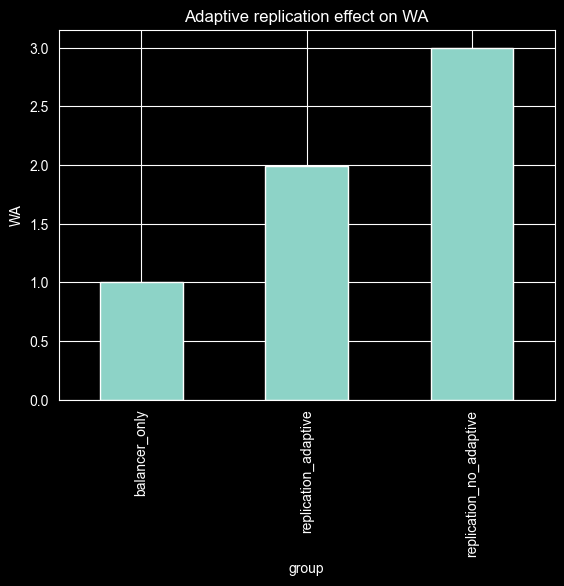

In [23]:
wa_group.plot(kind="bar")

plt.title("Adaptive replication effect on WA")

plt.ylabel("WA")

plt.show()

# CPU vs MEM Latency

In [24]:
df["is_cpu"] = df["endpoint"].str.startswith("cpu")

lat_cpu_mem = (

    df
    .groupby(["method", "is_cpu"])["latency_ms"]
    .mean()
    .unstack()
)

lat_cpu_mem

is_cpu,False,True
method,,
airm | hedged | adaptive,15525.259811,14283.998246
airm | hedged | no_adaptive,15128.077079,14115.467438
airm | no_replication,15030.549184,13810.985411
airm | speculative | adaptive,15585.185002,14780.544761
airm | speculative | no_adaptive,16547.928801,15611.327940
electre | hedged | adaptive,15630.573606,13781.076967
electre | hedged | no_adaptive,15426.214927,14515.334881
electre | no_replication,14830.486114,13900.513367
electre | speculative | adaptive,15687.195457,14704.861300


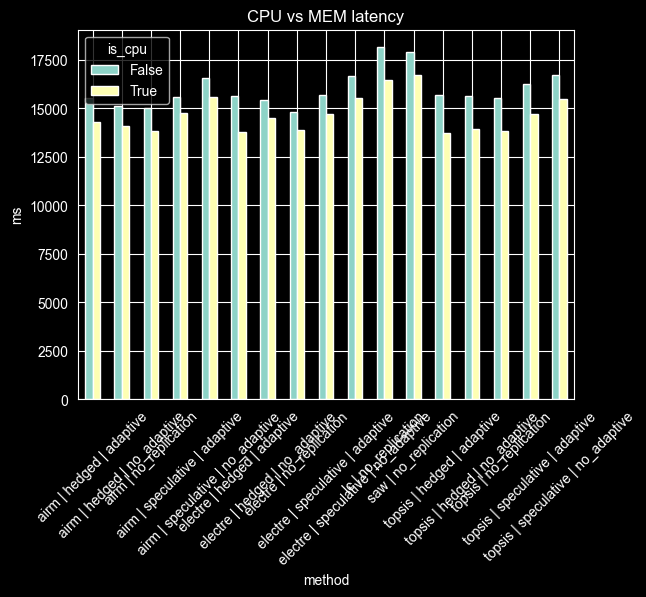

In [25]:
lat_cpu_mem.plot(kind="bar")

plt.title("CPU vs MEM latency")

plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

In [26]:
best_mean = latency_stats["mean"].idxmin()
best_p95 = latency_stats["p95"].idxmin()
best_wa = wa_stats["mean"].idxmin()

print("Best mean latency:", best_mean)
print("Best p95 latency:", best_p95)
print("Best WA:", best_wa)

Best mean latency: electre | no_replication
Best p95 latency: airm | speculative | adaptive
Best WA: airm | no_replication


# Сравнение с HAProxy

In [27]:
HAPROXY_DIR = Path("../assets/experiments/haproxy__1-4_secs")


def load_haproxy(folder):
    dfs = []

    for file in folder.glob("*.json"):
        data = load_experiment(file)

        name = file.stem.replace("haproxy_", "")
        method = f"haproxy | {name}"

        rows = []

        for req in data["requests"]:
            upstream = req.get("upstream", {})
            signals = req.get("signals", {})

            winner = upstream.get("winner_socket")

            rows.append({
                "method": method,
                "group": "haproxy",

                "req_id": req["req_id"],
                "endpoint": req["endpoint"],

                "latency_ms": req["latency_ms"],
                "status": req["status"],
                "ok": req["ok"],

                "winner_socket": winner,
                "replicas": 1,

                "cpu_util": signals.get("cpu_util"),
                "mem_util": signals.get("mem_util"),
                "cpu_burn": signals.get("cpu_burn"),
                "mem_burn": signals.get("mem_burn"),
            })

        dfs.append(pd.DataFrame(rows))

    return dfs


haproxy_dfs = load_haproxy(HAPROXY_DIR)

df_haproxy = pd.concat(haproxy_dfs, ignore_index=True)

df_haproxy.head()

,method,group,req_id,endpoint,latency_ms,status,ok,winner_socket,replicas,cpu_util,mem_util,cpu_burn,mem_burn
0,haproxy | leastconn,haproxy,req-0,mem?seconds=1&mb=75,1071.7843,200,True,n1_p8001,1,15.3,17.3,None,True
1,haproxy | leastconn,haproxy,req-1,mem?seconds=2&mb=75,2078.7392,200,True,n1_p8002,1,31.4,18.0,None,True
2,haproxy | leastconn,haproxy,req-2,cpu?seconds=3,3017.2059,200,True,n2_p8001,1,33.9,18.0,True,None
3,haproxy | leastconn,haproxy,req-3,cpu?seconds=1,1081.3741,200,True,n2_p8006,1,17.8,17.3,True,None
4,haproxy | leastconn,haproxy,req-4,cpu?seconds=3,3051.2834,200,True,n3_p8001,1,34.1,18.2,True,None


In [28]:
df_all = pd.concat([df, df_haproxy], ignore_index=True)
df_all["backend"] = df_all["backend_port"].fillna(df_all["winner_socket"])
df_all.head()

,method,group,req_id,endpoint,latency_ms,status,ok,error_kind,error,winner_socket,backend_port,replicas,cpu_util,mem_util,cpu_burn,mem_burn,algorithm,is_cpu,backend
0,airm | no_replication,balancer_only,req-0,mem?seconds=15&mb=75,20399.3242,200,True,None,None,GQW1_50051,8004.0,1,39.4,19.7,None,True,airm,False,8004.0
1,airm | no_replication,balancer_only,req-1,mem?seconds=14&mb=75,14201.1436,200,True,None,None,GQW2_50051,8001.0,1,36.9,19.7,None,True,airm,False,8001.0
2,airm | no_replication,balancer_only,req-2,cpu?seconds=11,11039.0685,200,True,None,None,GQW2_50051,8001.0,1,43.7,18.8,True,None,airm,True,8001.0
3,airm | no_replication,balancer_only,req-3,cpu?seconds=15,15037.3797,200,True,None,None,GQW6_50051,8001.0,1,41.9,19.7,True,None,airm,True,8001.0
4,airm | no_replication,balancer_only,req-4,mem?seconds=11&mb=75,11134.7649,200,True,None,None,GQW6_50051,8001.0,1,43.5,18.7,None,True,airm,False,8001.0


In [29]:
df_balancing_only = df_all[
    df_all["group"].isin(["balancer_only", "haproxy"])
].copy()

print("Methods in df_balancing_only:")
print(sorted(df_balancing_only["method"].unique()))

df_balancing_only["backend"] = (
    df_balancing_only["backend_port"]
    .astype("string")
    .fillna(df_balancing_only["winner_socket"])
)

df_balancing_only["backend_clean"] = (
    df_balancing_only["backend"]
    .astype(str)
    .str.split("_")
    .str[-1]
    .str.replace("p", "", regex=False)
)

print(df_balancing_only[["backend", "backend_clean"]].head(20))

Methods in df_balancing_only:
['airm | no_replication', 'electre | no_replication', 'haproxy | leastconn', 'haproxy | random', 'haproxy | roundrobin', 'lc | no_replication', 'saw | no_replication', 'topsis | no_replication']
   backend backend_clean
0   8004.0        8004.0
1   8001.0        8001.0
2   8001.0        8001.0
3   8001.0        8001.0
4   8001.0        8001.0
5   8003.0        8003.0
6   8003.0        8003.0
7   8003.0        8003.0
8   8005.0        8005.0
9   8005.0        8005.0
10  8005.0        8005.0
11  8005.0        8005.0
12  8001.0        8001.0
13  8004.0        8004.0
14  8001.0        8001.0
15  8001.0        8001.0
16  8003.0        8003.0
17  8006.0        8006.0
18  8006.0        8006.0
19  8003.0        8003.0


## Сравнение HAProxy алгоритмов

In [30]:
lat_compare = (
    df_balancing_only
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p95=p95,
        p99=p99
    )
    .sort_values("mean")
)

lat_compare

,mean,p95,p99
method,,,
haproxy | random,5622.297128,16970.215820,19414.030993
haproxy | leastconn,5709.932831,16793.308155,19427.507929
haproxy | roundrobin,5985.620070,19373.330580,19453.431726
electre | no_replication,14357.129986,23068.532915,33577.373395
airm | no_replication,14414.669479,23863.939220,36492.537825
topsis | no_replication,14712.644014,24654.237880,33949.617646
lc | no_replication,17289.543829,36952.810005,45306.836352
saw | no_replication,17291.975337,39008.382060,45583.276771


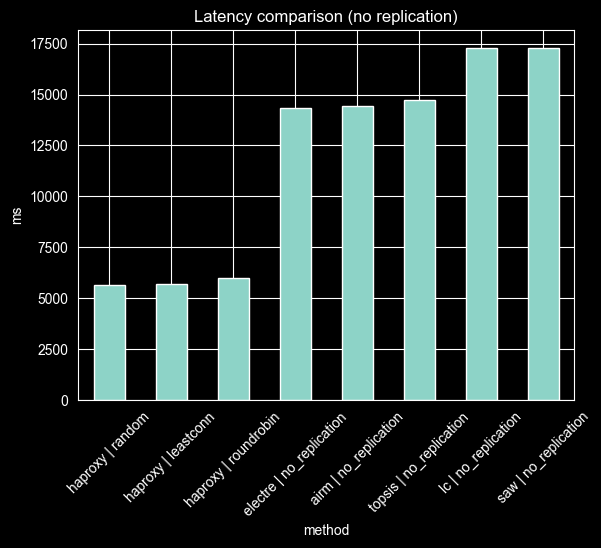

In [31]:
lat_compare["mean"].plot(kind="bar")

plt.title("Latency comparison (no replication)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

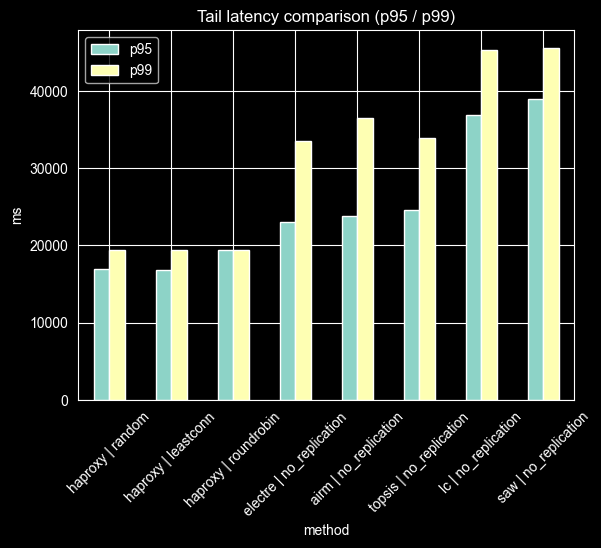

In [32]:
lat_compare[["p95", "p99"]].plot(kind="bar")

plt.title("Tail latency comparison (p95 / p99)")
plt.ylabel("ms")

plt.xticks(rotation=45)

plt.show()

## Балансировка нагрузки HAProxy

In [33]:
socket_counts_balancing = (
    df_balancing_only
    .dropna(subset=["backend_clean"])
    .groupby(["method", "backend_clean"])
    .size()
    .reset_index(name="count")
)

print("Methods in socket_counts_balancing:")
print(sorted(socket_counts_balancing["method"].unique()))

Methods in socket_counts_balancing:
['airm | no_replication', 'electre | no_replication', 'haproxy | leastconn', 'haproxy | random', 'haproxy | roundrobin', 'lc | no_replication', 'saw | no_replication', 'topsis | no_replication']


In [34]:
imbalance = socket_counts_balancing.groupby("method")["count"].agg(
    mean="mean",
    std="std"
)

imbalance["cv"] = imbalance["std"] / imbalance["mean"]

imbalance.sort_values("cv")

,mean,std,cv
method,,,
haproxy | leastconn,160.500000,7.765307,0.048382
haproxy | roundrobin,158.166667,8.542053,0.054007
haproxy | random,164.333333,25.184651,0.153253
airm | no_replication,163.666667,25.121040,0.153489
electre | no_replication,164.833333,33.558407,0.203590
topsis | no_replication,165.166667,41.092173,0.248792
saw | no_replication,153.000000,58.350664,0.381377
lc | no_replication,153.833333,87.492666,0.568750


In [35]:
order = imbalance["cv"].sort_values().index

socket_counts_balancing["method"] = pd.Categorical(
    socket_counts_balancing["method"],
    categories=order,
    ordered=True
)

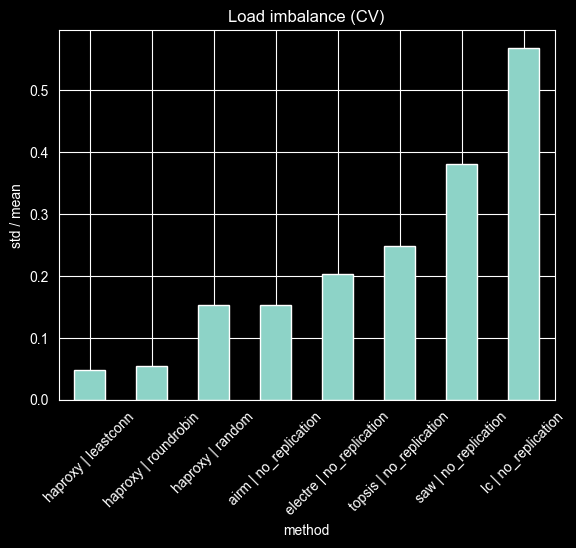

In [36]:
imbalance["cv"].sort_values().plot(kind="bar")

plt.title("Load imbalance (CV)")
plt.ylabel("std / mean")

plt.xticks(rotation=45)

plt.show()

<Figure size 1200x600 with 0 Axes>

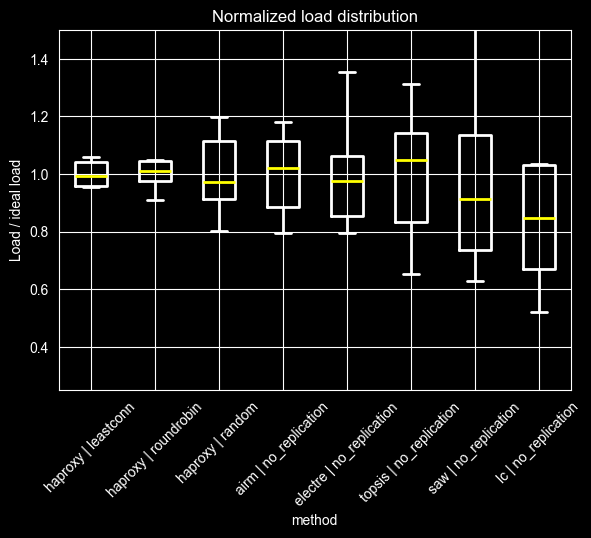

In [37]:
socket_counts_balancing["normalized"] = (
        socket_counts_balancing["count"] /
        socket_counts_balancing.groupby("method")["count"].transform("mean")
)

plt.figure(figsize=(12, 6))

socket_counts_balancing.boxplot(
    column="normalized",
    by="method",
    rot=45,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color="yellow"),
)

plt.title("Normalized load distribution")
plt.suptitle("")
plt.ylabel("Load / ideal load")
plt.ylim(0.25, 1.5)
plt.show()

<Figure size 1000x600 with 0 Axes>

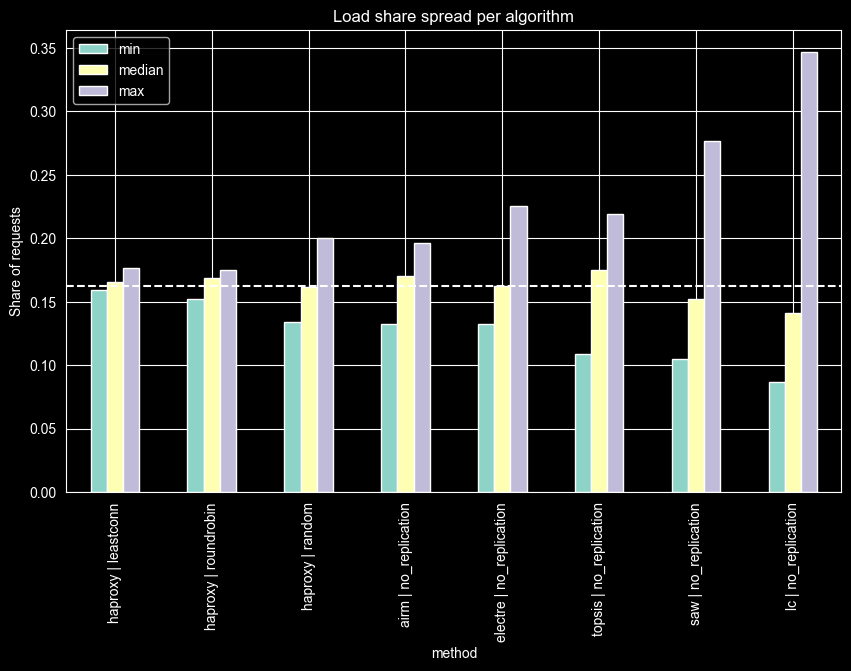

In [38]:
plt.figure(figsize=(10,6))

rows = []

for method, group in socket_counts_balancing.groupby("method"):
    counts = group["count"].values
    share = counts / counts.sum()

    rows.append({
        "method": method,
        "min": share.min(),
        "median": np.median(share),
        "max": share.max()
    })

share_df = pd.DataFrame(rows).set_index("method")

share_df.plot(kind="bar", figsize=(10,6))

plt.axhline(share_df["median"].mean(), linestyle="--")

plt.ylabel("Share of requests")
plt.title("Load share spread per algorithm")

plt.show()

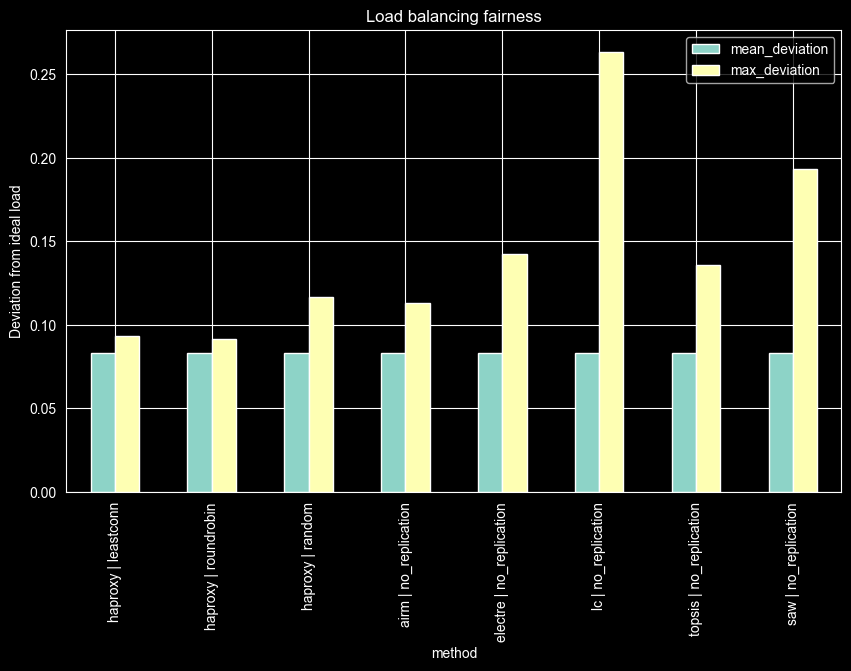

In [39]:
rows = []

n_servers = socket_counts_balancing["backend_clean"].nunique()
ideal = 1 / n_servers

for method, group in socket_counts_balancing.groupby("method"):

    counts = group["count"].values
    share = counts / counts.sum()

    deviation = np.abs(share - ideal)

    rows.append({
        "method": method,
        "mean_deviation": deviation.mean(),
        "max_deviation": deviation.max()
    })

dev_df = pd.DataFrame(rows).set_index("method")

dev_df.sort_values("mean_deviation").plot(kind="bar", figsize=(10,6))

plt.ylabel("Deviation from ideal load")
plt.title("Load balancing fairness")

plt.show()

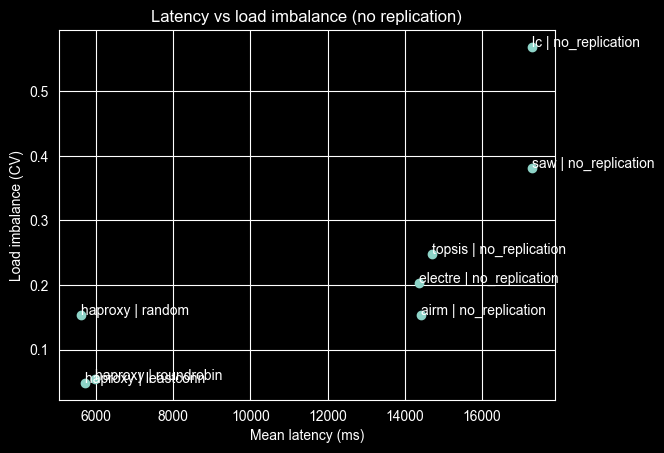

In [40]:
lat_mean = (
    df_balancing_only
    .groupby("method")["latency_ms"]
    .mean()
)

tradeoff = pd.concat([lat_mean, imbalance["cv"]], axis=1)

plt.scatter(tradeoff["latency_ms"], tradeoff["cv"])

for name, row in tradeoff.iterrows():
    plt.text(row["latency_ms"], row["cv"], name)

plt.xlabel("Mean latency (ms)")
plt.ylabel("Load imbalance (CV)")

plt.title("Latency vs load imbalance (no replication)")

plt.show()

## Числовые сравнения

In [41]:
lat_stats = (
    df_all
    .groupby("method")["latency_ms"]
    .agg(
        mean="mean",
        p50=p50,
        p95=p95,
        p99=p99
    )
)

my_algorithms = lat_stats[
    lat_stats.index.str.contains("no_replication")
]

haproxy_algorithms = lat_stats[
    lat_stats.index.str.contains("haproxy")
]

best_my = my_algorithms.sort_values("mean").iloc[0]
best_haproxy = haproxy_algorithms.sort_values("mean").iloc[0]

best_my_name = my_algorithms.sort_values("mean").index[0]
best_haproxy_name = haproxy_algorithms.sort_values("mean").index[0]

print("Best my algorithm:", best_my_name)
print("Best haproxy algorithm:", best_haproxy_name)

Best my algorithm: electre | no_replication
Best haproxy algorithm: haproxy | random


In [42]:
mean_gain = (best_haproxy["mean"] - best_my["mean"]) / best_haproxy["mean"] * 100
p50_gain = (best_haproxy["p50"] - best_my["p50"]) / best_haproxy["p50"] * 100
p95_gain = (best_haproxy["p95"] - best_my["p95"]) / best_haproxy["p95"] * 100
p99_gain = (best_haproxy["p99"] - best_my["p99"]) / best_haproxy["p99"] * 100

print("\nLatency improvement vs HAProxy round-robin:")

print(f"Mean latency improvement: {mean_gain:.2f}%")
print(f"P50 latency improvement: {p50_gain:.2f}%")
print(f"P95 latency improvement: {p95_gain:.2f}%")
print(f"P99 latency improvement: {p99_gain:.2f}%")


Latency improvement vs HAProxy round-robin:
Mean latency improvement: -155.36%
P50 latency improvement: -228.19%
P95 latency improvement: -35.94%
P99 latency improvement: -72.95%


In [43]:
imbalance = (
    socket_counts_balancing
    .groupby("method")["count"]
    .agg(mean="mean", std="std")
)

imbalance["cv"] = imbalance["std"] / imbalance["mean"]

my_imbalance = imbalance[
    imbalance.index.str.contains("no_replication")
]

haproxy_imbalance = imbalance[
    imbalance.index.str.contains("haproxy")
]
best_my_cv_name = my_imbalance["cv"].idxmin()
best_haproxy_cv_name = haproxy_imbalance["cv"].idxmin()

best_my_cv = imbalance.loc[best_my_cv_name, "cv"]
best_haproxy_cv = imbalance.loc[best_haproxy_cv_name, "cv"]

print("Best my algorithm (CV):", best_my_cv_name)
print("Best haproxy algorithm (CV):", best_haproxy_cv_name)

print("\nCV values:")
print("My algorithm CV:", best_my_cv)
print("HAProxy CV:", best_haproxy_cv)

cv_gain = (best_haproxy_cv - best_my_cv) / best_haproxy_cv * 100

print(f"\nLoad balance improvement: {cv_gain:.2f}%")

Best my algorithm (CV): airm | no_replication
Best haproxy algorithm (CV): haproxy | leastconn

CV values:
My algorithm CV: 0.15348904471381422
HAProxy CV: 0.048381977964653405

Load balance improvement: -217.24%


In [44]:
imbalance.sort_values("cv")

,mean,std,cv
method,,,
haproxy | leastconn,160.500000,7.765307,0.048382
haproxy | roundrobin,158.166667,8.542053,0.054007
haproxy | random,164.333333,25.184651,0.153253
airm | no_replication,163.666667,25.121040,0.153489
electre | no_replication,164.833333,33.558407,0.203590
topsis | no_replication,165.166667,41.092173,0.248792
saw | no_replication,153.000000,58.350664,0.381377
lc | no_replication,153.833333,87.492666,0.568750


# Сравнение ошибок

In [45]:
error_stats = (
    df
    .groupby("method")["ok"]
    .agg(
        total="count",
        success="sum"
    )
)

error_stats["errors"] = error_stats["total"] - error_stats["success"]
error_stats["error_rate"] = error_stats["errors"] / error_stats["total"]

error_stats.sort_values("error_rate", ascending=False)

,total,success,errors,error_rate
method,,,,
saw | no_replication,1000,918,82,0.082
lc | no_replication,1000,923,77,0.077
airm | no_replication,1000,982,18,0.018
topsis | hedged | adaptive,1000,984,16,0.016
airm | hedged | adaptive,1000,986,14,0.014
electre | no_replication,1000,989,11,0.011
topsis | no_replication,1000,991,9,0.009
topsis | speculative | adaptive,1000,995,5,0.005
electre | hedged | adaptive,1000,996,4,0.004


In [46]:
error_by_group = (
    df
    .groupby("group")["ok"]
    .agg(
        total="count",
        success="sum"
    )
)

error_by_group["errors"] = error_by_group["total"] - error_by_group["success"]
error_by_group["error_rate"] = error_by_group["errors"] / error_by_group["total"]

error_by_group

,total,success,errors,error_rate
group,,,,
balancer_only,5000,4803,197,0.039400
replication_adaptive,6000,5960,40,0.006667
replication_no_adaptive,6000,5997,3,0.000500


In [47]:
baseline_err = error_by_group.loc["balancer_only", "error_rate"]
rep_no_err = error_by_group.loc["replication_no_adaptive", "error_rate"]
rep_ad_err = error_by_group.loc["replication_adaptive", "error_rate"]

replication_gain = (baseline_err - rep_no_err) / baseline_err * 100
adaptive_gain = (rep_no_err - rep_ad_err) / rep_no_err * 100

print(f"Replication error reduction: {replication_gain:.2f}%")
print(f"Adaptive replication improvement: {adaptive_gain:.2f}%")

Replication error reduction: 98.73%
Adaptive replication improvement: -1233.33%


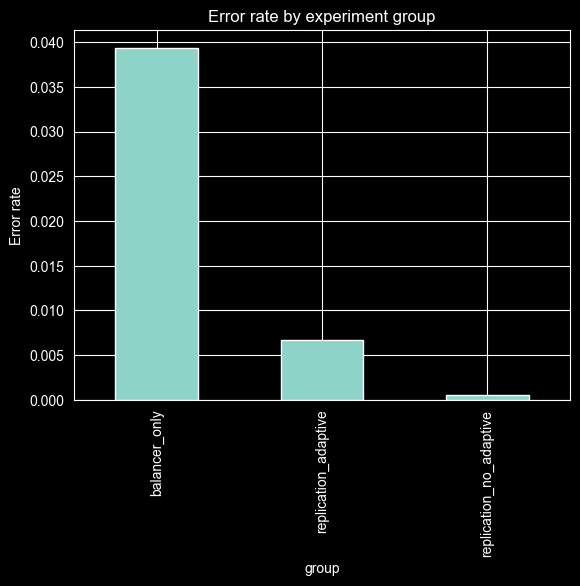

In [48]:
error_by_group["error_rate"].plot(kind="bar")

plt.title("Error rate by experiment group")
plt.ylabel("Error rate")

plt.show()

In [49]:
error_df = (
    df
    .groupby("error_kind")
    .size()
    .reset_index(name="count")
)

error_df["rate"] = error_df["count"] / len(df)

print(error_df.sort_values("count", ascending=False))

Empty DataFrame
Columns: [error_kind, count, rate]
Index: []


In [50]:
error_kinds = (
    df
    .assign(error_kind=df["ok"].map({True: "none", False: "request_error"}))
    .groupby("error_kind")
    .size()
    .reset_index(name="count")
)

error_kinds["rate"] = error_kinds["count"] / len(df)

print(error_kinds.sort_values("count", ascending=False))

      error_kind  count      rate
0           none  16760  0.985882
1  request_error    240  0.014118


In [51]:

error_status = (
    df
    .groupby("status")
    .size()
    .reset_index(name="count")
)

error_status["rate"] = error_status["count"] / len(df)

print(error_status.sort_values("count", ascending=False))

   status  count      rate
0     200  16760  0.985882
2     504    228  0.013412
1     500     12  0.000706


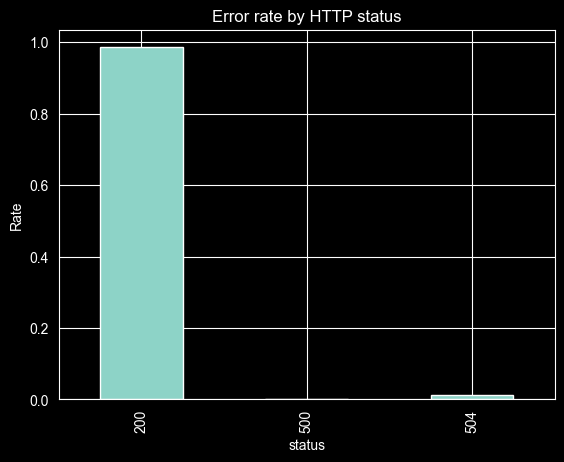

In [52]:

error_status.set_index("status")["rate"].plot(kind="bar")

plt.title("Error rate by HTTP status")
plt.ylabel("Rate")

plt.show()

In [53]:
baseline = df[df["group"] == "balancer_only"]

baseline["latency_ms"].describe(percentiles=[0.95,0.99])

count     5000.000000
mean     15613.192529
std       6575.068032
min      10018.947200
95%      31139.949705
99%      42403.310484
max      45981.449200
Name: latency_ms, dtype: float64